# Transfer Learning

##Giorgio Lazzarinetti - My Contacts
For any questions or doubts you can find my contacts here:

giorgiolazzarinetti@gmail.it giorgio.lazzarinetti@unimib.it

### Notebook Outline

* **Transfer Learning Introduction**
* **Hints for Project Proposal**
* **Transfer Learning in Computer Vision**

## Transfer Learning

### What is Transfer Learning?

Transfer learning is a machine learning technique where a model trained on one task is re-purposed on a second related task.

Transfer learning is popular in deep learning given the enormous resources required to train deep learning models or the large and challenging datasets on which deep learning models are trained.

there are 2 ways of using Transfer Learning:
- Develop Model Approach
- Pre-trained Model Approach

#### Develop Model Approach
- **Select Source Task**. You must select a related predictive modeling problem with an abundance of data where there is some relationship in the input data, output data, and/or concepts learned during the mapping from input to output data.
- **Develop Source Model**. Next, you must develop a skillful model for this first task. The model must be better than a naive model to ensure that some feature learning has been performed.
- **Reuse Model**. The model fit on the source task can then be used as the starting point for a model on the second task of interest. This may involve using all or parts of the model, depending on the modeling technique used.
- **Tune Model**. Optionally, the model may need to be adapted or refined on the input-output pair data available for the task of interest.

#### Pre-Trained Approach

- **Select Source Model**. A pre-trained source model is chosen from available models. Many research institutions release models on large and challenging datasets that may be included in the pool of candidate models from which to choose from.
- **Reuse Model**. The model pre-trained model can then be used as the starting point for a model on the second task of interest. This may involve using all or parts of the model, depending on the modeling technique used.
- **Tune Model**. Optionally, the model may need to be adapted or refined on the input-output pair data available for the task of interest.

This second type of transfer learning is common in the field of deep learning.

### Packages

In [1]:
%matplotlib inline

import random
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm


import torch
import torch.nn as nn
from torchsummary import summary
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# set the seed for reproducibility: built-in python, numpy, and pytorch
seed = 20
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed) # works for all devices (CPU and GPU)

In [3]:
device = torch.device('cpu')
#device = torch.device('cuda') # Uncomment this to run on GPU

### Develop Model Approach

In [4]:
class UniversalApprox(nn.Module):
  def __init__(self, num_units, dropout_rate):
    super().__init__()

    self.num_units = num_units
    self.dropout_rate = dropout_rate

    # dropout is a function that takes as input activations from the previous layer and
    # sets some of them at zero, according to the dropout rate value.

    self.dense1 = nn.Linear(1, self.num_units, bias=True)
    self.dense2 = nn.Linear(self.num_units, int(self.num_units), bias=True)
    self.dense3 = nn.Linear(int(self.num_units), int(self.num_units/2), bias=True)
    self.dense4 = nn.Linear(int(self.num_units/2), 1, bias=True)
    self.droput = nn.Dropout(p = self.dropout_rate)

  def forward(self, x):
    result = torch.tanh(self.dense1(x))
    result = self.droput(result)
    result = torch.tanh(self.dense2(result))
    result = self.droput(result)
    result = torch.tanh(self.dense3(result))
    result = self.droput(result)
    result = torch.tanh(self.dense4(result))
    return result

    #-----------------------------------------------------#
    #                   A custom method
    #-----------------------------------------------------#
    def extract_lin1(self, x):
        '''
        Extracts the activations of the first hidden layer
        '''

        return self.dense1(x)

In [5]:
num_samples = 512

train_inputs = torch.rand(num_samples)
noise = torch.randn(num_samples)

train_targets = torch.cos(8*train_inputs) + .01*noise

#for validation
valid_inputs = torch.rand(num_samples)
valid_targets = torch.cos(8*valid_inputs) + .01*noise

In [6]:
assert train_inputs[0] != valid_inputs[0]
assert train_targets[0] != valid_targets[0]

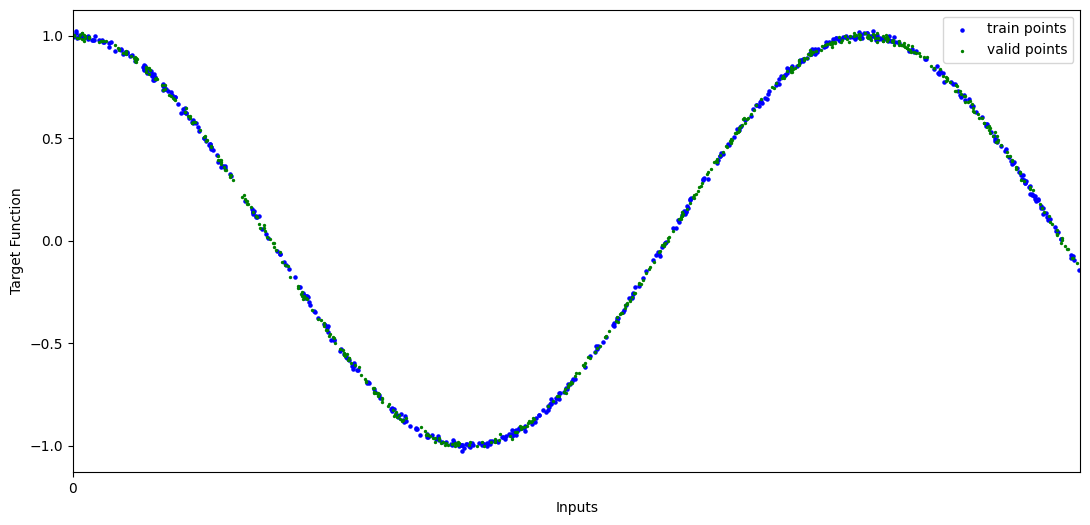

In [7]:
fig, ax = plt.subplots(figsize=(13,6))

ax.scatter(train_inputs, train_targets, c='b', s=5, label='train points')
ax.scatter(valid_inputs, valid_targets, c='g', s=2, label='valid points')
ax.set_xticks(range(0, 1))
plt.xlim(0, 1)
ax.set_xlabel('Inputs')
ax.set_ylabel('Target Function')
ax.legend(loc='upper right')
plt.show()

In [8]:
train_dataloader = DataLoader(TensorDataset(train_inputs, train_targets), batch_size= 256, shuffle=True)
valid_dataloader = DataLoader(TensorDataset(valid_inputs, valid_targets), batch_size= 256, shuffle=True)

In [9]:
model = UniversalApprox(num_units = 512, dropout_rate = .4)
model.to(device)

UniversalApprox(
  (dense1): Linear(in_features=1, out_features=512, bias=True)
  (dense2): Linear(in_features=512, out_features=512, bias=True)
  (dense3): Linear(in_features=512, out_features=256, bias=True)
  (dense4): Linear(in_features=256, out_features=1, bias=True)
  (droput): Dropout(p=0.4, inplace=False)
)

In [10]:
input_size = (1,)
summary(model, input_size)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 512]           1,024
           Dropout-2                  [-1, 512]               0
            Linear-3                  [-1, 512]         262,656
           Dropout-4                  [-1, 512]               0
            Linear-5                  [-1, 256]         131,328
           Dropout-6                  [-1, 256]               0
            Linear-7                    [-1, 1]             257
Total params: 395,265
Trainable params: 395,265
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 1.51
Estimated Total Size (MB): 1.53
----------------------------------------------------------------


In [11]:
def plot_loss(training_loss, validation_loss):
  plt.plot(range(len(training_loss)), training_loss, c='b', label='Loss Training')
  plt.plot(range(len(validation_loss)), validation_loss, c='r', label='Loss Validation')
  #plt.ylim(0.4, 0.8)
  plt.show()

Training model ...

 epoch 0
-- train loss 0.637, validation loss 0.789

 epoch 50
-- train loss 0.0671, validation loss 0.0395

 epoch 100
-- train loss 0.0526, validation loss 0.015

 epoch 150
-- train loss 0.0415, validation loss 0.0118

 epoch 200
-- train loss 0.0275, validation loss 0.0118

 epoch 250
-- train loss 0.0257, validation loss 0.014

 epoch 300
-- train loss 0.0261, validation loss 0.00823

 epoch 350
-- train loss 0.0267, validation loss 0.00838

 epoch 400
-- train loss 0.0225, validation loss 0.00918

 epoch 450
-- train loss 0.0202, validation loss 0.00704

 epoch 500
-- train loss 0.0215, validation loss 0.00748

 epoch 550
-- train loss 0.0174, validation loss 0.00749

 epoch 600
-- train loss 0.0199, validation loss 0.00738

 epoch 650
-- train loss 0.0179, validation loss 0.0052

 epoch 700
-- train loss 0.0169, validation loss 0.0062

 epoch 750
-- train loss 0.0158, validation loss 0.00691

 epoch 800
-- train loss 0.0157, validation loss 0.0054

 epoch 850

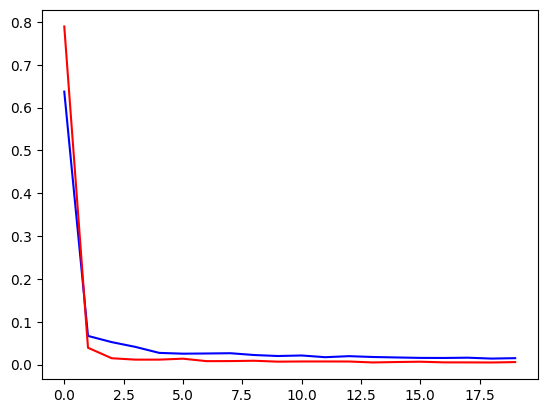

Loss Diff -0.01082622422836721


In [12]:
# Settings
num_epochs = 1000 #8000
learning_rate = 0.001 #0.0001

def training_step(net, criterion, optimizer):
    # set the model to train mode
    running_loss=0
    net.train()
    for batch_idx, (x, y) in enumerate(train_dataloader): # avoid for loop when batch is equal to input data size
      # add one dimension
      x = x.view(-1, 1)
      y = y.view(-1, 1)

      # transfer to device
      x, y = x.to(device), y.to(device)

      #forward pass
      model_pred = net(x)

      #loss function evaluation
      loss = criterion(model_pred, y)

      #initialize optimizer
      optimizer.zero_grad()

      # Backward pass: compute gradient of the loss with respect to model
      # parameters
      loss.backward()

      # Calling the step function on an Optimizer makes an update to its
      # parameters
      optimizer.step()

      running_loss+=loss.item()

    return running_loss/(batch_idx+1)

def validation_step(net, criterion, optimizer):

    running_loss=0
    # set the model to train mode
    net.eval()
    for batch_idx, (x, y) in enumerate(valid_dataloader): # avoid for loop when batch is equal to input data size

      # add one dimension
      x = x.view(-1, 1)
      y = y.view(-1, 1)

      # transfer to device
      x, y = x.to(device), y.to(device)

      # While, we are performing inference, we don't compute gradients, and thus, don't need to cache these values.
      # Infact, no graph needs to be create during inference as it will lead to useless consumption of memory.

      with torch.no_grad():
        model_pred = net(x)

        loss = criterion(model_pred, y)

        running_loss+=loss.item()
    return running_loss/(batch_idx+1)


model_dict = {'model': model}


for model in model_dict.keys():
  print('Training {} ...'.format(model))
  criterion = nn.MSELoss(reduction = 'mean')
  optimizer = torch.optim.Adam(model_dict[model].parameters(), lr=learning_rate)

  tr_loss, va_loss = [], []

  for epoch in range(num_epochs):
    tr_loss_step = training_step(model_dict[model], criterion = criterion, optimizer = optimizer)
    if epoch % 50 == 0:
      va_loss_step = validation_step(model_dict[model], criterion = criterion, optimizer = optimizer)
      va_loss.append(va_loss_step)
      tr_loss.append(tr_loss_step)
      print(f'\n epoch {epoch}')
      print(f'-- train loss {tr_loss_step:.3}, validation loss {va_loss_step:.3}')


  plot_loss(tr_loss, va_loss)
  loss_diff = np.array(va_loss)- np.array(tr_loss)
  print('Loss Diff', np.mean(loss_diff[-10:]))

In [13]:
all_preds = []

for model in model_dict.keys():
  # Disabling gradient calculation is useful for inference, since it will reduce memory
  # consumption for computations that would otherwise have requires_grad=True.
  with torch.no_grad():
    model_dict[model].eval()
    pred = model_dict[model](train_inputs.view(-1,1).to(device)).detach().to('cpu')
    all_preds.append(pred)

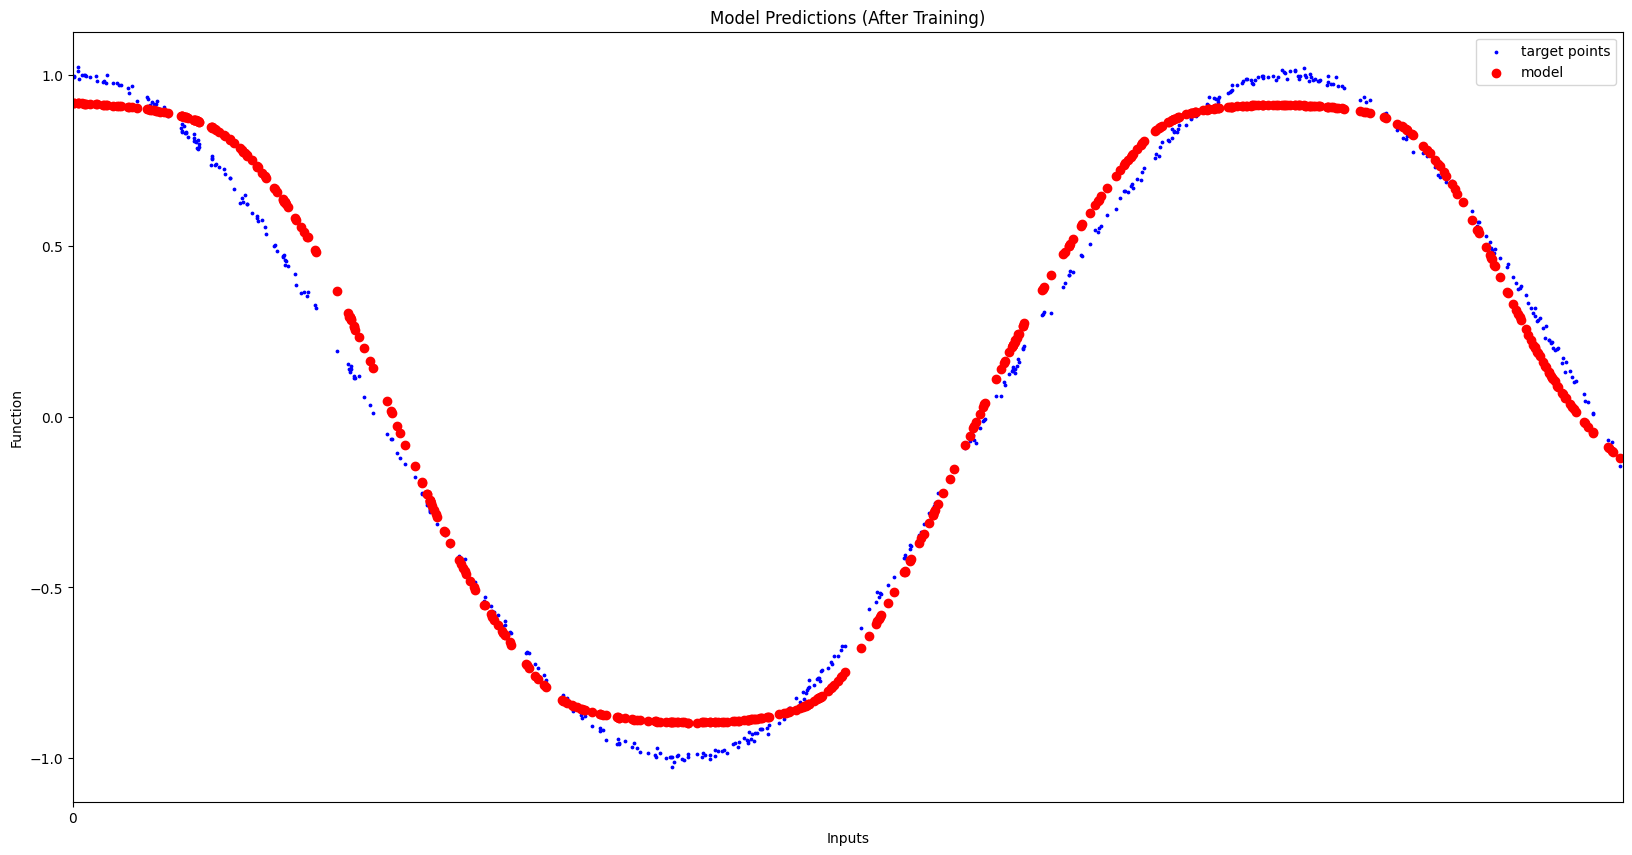

In [14]:
fig, ax = plt.subplots(figsize=(20,10))

#pred_over = np.load('./overfitted_model.npy')
#pred_corr = np.load('./correct_model.npy')

ax.scatter(train_inputs, train_targets, c='b', s=3, label='target points')
for i, model in enumerate(model_dict.keys()):
  colors = ['r', 'm', 'g', 'k']
  ax.scatter(train_inputs, all_preds[i], c=colors[i], label=model)
  #ax.scatter(train_inputs, all_preds[1], c='m', s=5, label='model 2')
  #ax.scatter(inputs, all_preds[2], c='g', s=5, label='model 3')

ax.set_xticks(range(0, 1))
plt.xlim(0, 1)
ax.set_xlabel('Inputs')
ax.set_ylabel('Function')
ax.set_title(f'Model Predictions (After Training)')
ax.legend(loc='upper right')
plt.show()

### Save Model Parameters

In [15]:
model_dict['model'].state_dict()

OrderedDict([('dense1.weight',
              tensor([[-0.4589],
                      [ 0.0579],
                      [-0.3361],
                      [-0.4602],
                      [ 0.2387],
                      [ 0.1355],
                      [ 0.8698],
                      [ 0.5292],
                      [ 0.7828],
                      [ 0.6330],
                      [ 0.4149],
                      [-0.0953],
                      [-0.5508],
                      [ 0.7286],
                      [-0.9357],
                      [ 0.4735],
                      [ 0.8341],
                      [-0.5429],
                      [ 0.2536],
                      [-1.0364],
                      [-0.5542],
                      [-0.5279],
                      [ 0.2037],
                      [ 0.4446],
                      [-0.7258],
                      [ 0.1974],
                      [-0.4824],
                      [ 0.8012],
                      [ 0.8664],
            

In [16]:
import os
folder_save = "models/mlp_init"
os.makedirs(folder_save, exist_ok=True)
filename = os.path.join(folder_save, "model.pt")
torch.save(model_dict['model'].state_dict(), filename)

  Create an universalApprox with more layers

In [17]:
class TransferUniversalApprox(nn.Module):
  def __init__(self, num_units, dropout_rate):
    super().__init__()

    self.num_units = num_units
    self.dropout_rate = dropout_rate

    # dropout is a function that takes as input activations from the previous layer and
    # sets some of them at zero, according to the dropout rate value.

    self.dense1 = nn.Linear(1, self.num_units, bias=True)
    self.dense2 = nn.Linear(self.num_units, int(self.num_units), bias=True)
    self.dense3 = nn.Linear(int(self.num_units), int(self.num_units/2), bias=True)
    self.dense4 = nn.Linear(int(self.num_units/2), int(self.num_units/2), bias=True)
    self.dense5 = nn.Linear(int(self.num_units/2), 1, bias=True)
    self.droput = nn.Dropout(p = self.dropout_rate)

  def forward(self, x):
    result = torch.tanh(self.dense1(x))
    result = self.droput(result)
    result = torch.tanh(self.dense2(result))
    result = self.droput(result)
    result = torch.tanh(self.dense3(result))
    result = self.droput(result)
    result = torch.tanh(self.dense4(result))
    result = self.droput(result)
    result = torch.tanh(self.dense5(result))
    return result

    #-----------------------------------------------------#
    #                   A custom method
    #-----------------------------------------------------#
    def extract_lin1(self, x):
        '''
        Extracts the activations of the first hidden layer
        '''

        return self.dense1(x)

In [18]:
new_model = UniversalApprox(num_units = 512, dropout_rate = .2)
new_model.to(device)

UniversalApprox(
  (dense1): Linear(in_features=1, out_features=512, bias=True)
  (dense2): Linear(in_features=512, out_features=512, bias=True)
  (dense3): Linear(in_features=512, out_features=256, bias=True)
  (dense4): Linear(in_features=256, out_features=1, bias=True)
  (droput): Dropout(p=0.2, inplace=False)
)

In [19]:
transfer_same_nof_model = UniversalApprox(num_units = 512, dropout_rate = .2)
transfer_same_f_model = UniversalApprox(num_units = 512, dropout_rate = .2)
transfer_new_nof_model = TransferUniversalApprox(num_units = 512, dropout_rate = .2)
transfer_new_f_model =  TransferUniversalApprox(num_units = 512, dropout_rate = .2)

model_dict['transfer_same_nof_model']= transfer_same_nof_model
model_dict['transfer_same_f_model']= transfer_same_f_model
model_dict['transfer_new_nof_model']= transfer_new_nof_model
model_dict['transfer_new_f_model']= transfer_new_f_model
model_dict['new_model'] = new_model

 let's freeze some layers

In [20]:
for param in new_model.named_parameters():
  print(param)

('dense1.weight', Parameter containing:
tensor([[ 0.1502],
        [ 0.4618],
        [-0.0458],
        [-0.3374],
        [-0.7206],
        [ 0.4721],
        [-0.1981],
        [ 0.9794],
        [-0.3221],
        [ 0.8558],
        [-0.1235],
        [ 0.1878],
        [ 0.0525],
        [-0.5920],
        [-0.3143],
        [ 0.0951],
        [-0.5499],
        [ 0.8575],
        [-0.1784],
        [-0.6991],
        [-0.5646],
        [-0.4115],
        [-0.0412],
        [-0.6755],
        [ 0.3508],
        [-0.1371],
        [-0.5883],
        [-0.6556],
        [ 0.0956],
        [-0.7546],
        [-0.0142],
        [-0.5597],
        [-0.4436],
        [-0.3832],
        [-0.2065],
        [-0.8976],
        [-0.5707],
        [-0.0877],
        [ 0.2156],
        [-0.4146],
        [-0.2968],
        [-0.3358],
        [ 0.0343],
        [-0.9875],
        [-0.5361],
        [-0.1206],
        [-0.9228],
        [ 0.2530],
        [ 0.1592],
        [ 0.1374],
        [ 

In [21]:
count=0
for name, param in model_dict['transfer_same_f_model'].named_parameters():
  if count<6:
    param.requires_grad=False
    count+=1
  print(name, param.requires_grad)

dense1.weight False
dense1.bias False
dense2.weight False
dense2.bias False
dense3.weight False
dense3.bias False
dense4.weight True
dense4.bias True


In [22]:
count=0
for name, param in model_dict['transfer_new_f_model'].named_parameters():
  if count<6:
    param.requires_grad=False
    count+=1
  print(name, param.requires_grad)

dense1.weight False
dense1.bias False
dense2.weight False
dense2.bias False
dense3.weight False
dense3.bias False
dense4.weight True
dense4.bias True
dense5.weight True
dense5.bias True


now we load in the new model the previously trained parameters. Thew first 4 layers have been freezed, so during training they will not be changed, while only the last 3 layers will be updated

In [23]:
model_dict['model'].load_state_dict(torch.load(filename))

<All keys matched successfully>

In [24]:
state_dict = model_dict['model'].state_dict()

In [25]:
state_dict_transfer_same = model_dict['transfer_same_f_model'].state_dict()
state_dict_transfer_same['dense1.weight'] = state_dict['dense1.weight']
state_dict_transfer_same['dense1.bias'] = state_dict['dense1.bias']
state_dict_transfer_same['dense2.weight'] = state_dict['dense2.weight']
state_dict_transfer_same['dense2.bias'] = state_dict['dense2.bias']
state_dict_transfer_same['dense3.weight'] = state_dict['dense3.weight']
state_dict_transfer_same['dense3.bias'] = state_dict['dense3.bias']

model_dict['transfer_same_nof_model'].load_state_dict(state_dict_transfer_same)
model_dict['transfer_same_f_model'].load_state_dict(state_dict_transfer_same)


state_dict_transfer_new = model_dict['transfer_new_f_model'].state_dict()
state_dict_transfer_new['dense1.weight'] = state_dict['dense1.weight']
state_dict_transfer_new['dense1.bias'] = state_dict['dense1.bias']
state_dict_transfer_new['dense2.weight'] = state_dict['dense2.weight']
state_dict_transfer_new['dense2.bias'] = state_dict['dense2.bias']
state_dict_transfer_new['dense3.weight'] = state_dict['dense3.weight']
state_dict_transfer_new['dense3.bias'] = state_dict['dense3.bias']

model_dict['transfer_new_nof_model'].load_state_dict(state_dict_transfer_new)
model_dict['transfer_new_f_model'].load_state_dict(state_dict_transfer_new)

<All keys matched successfully>

In [26]:
for name, param in model_dict['transfer_new_f_model'].named_parameters():
  print('Parameter {} is freezed {}'.format(name, 1-param.requires_grad==True))

Parameter dense1.weight is freezed True
Parameter dense1.bias is freezed True
Parameter dense2.weight is freezed True
Parameter dense2.bias is freezed True
Parameter dense3.weight is freezed True
Parameter dense3.bias is freezed True
Parameter dense4.weight is freezed False
Parameter dense4.bias is freezed False
Parameter dense5.weight is freezed False
Parameter dense5.bias is freezed False


In [27]:
num_samples = 512

train_inputs = torch.rand(num_samples)
noise = torch.randn(num_samples)

train_targets = torch.cos(8*train_inputs) + .7*noise

#for validation
valid_inputs = torch.rand(num_samples)
valid_targets = torch.cos(8*valid_inputs) + .7*noise

In [28]:
assert train_inputs[0] != valid_inputs[0]
assert train_targets[0] != valid_targets[0]

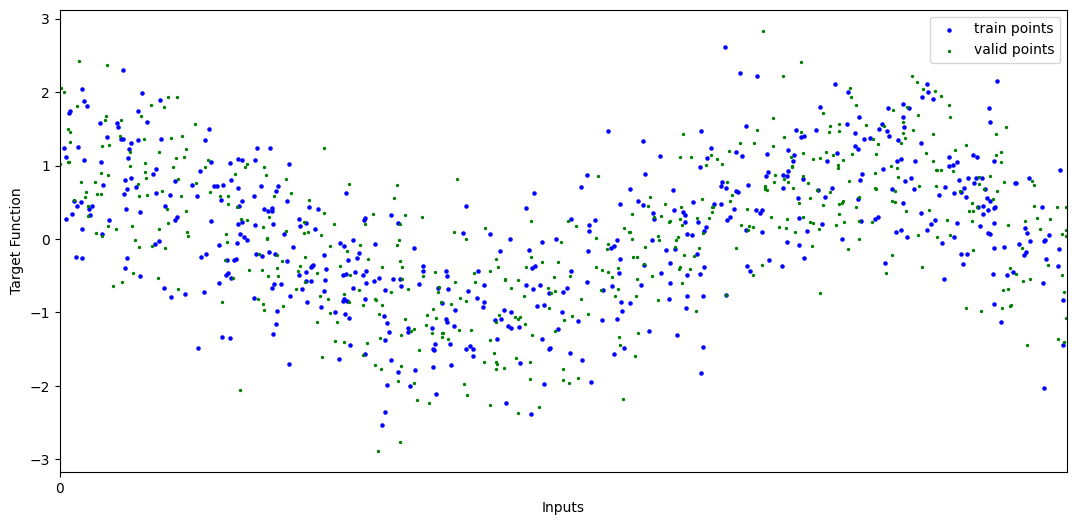

In [29]:
fig, ax = plt.subplots(figsize=(13,6))

ax.scatter(train_inputs, train_targets, c='b', s=5, label='train points')
ax.scatter(valid_inputs, valid_targets, c='g', s=2, label='valid points')
ax.set_xticks(range(0, 1))
plt.xlim(0, 1)
ax.set_xlabel('Inputs')
ax.set_ylabel('Target Function')
#ax.set_title(f'Distribution of sum of two different dices')
ax.legend(loc='upper right')
plt.show()

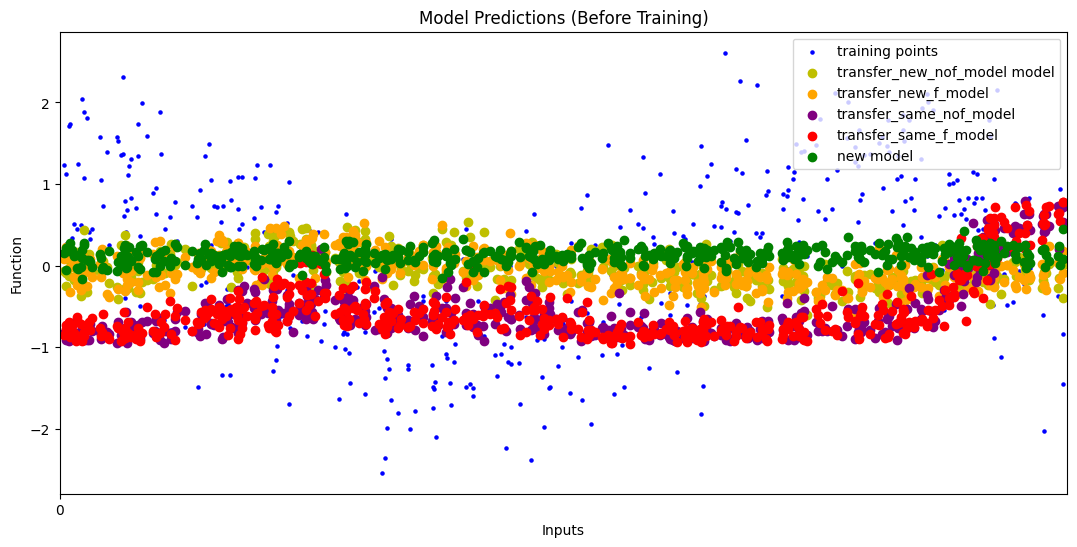

In [30]:
pred_transfer_new_nof_model = model_dict['transfer_new_nof_model'](train_inputs.view(-1,1).to(device)).detach().to('cpu')
pred_transfer_new_f_model = model_dict['transfer_new_f_model'](train_inputs.view(-1,1).to(device)).detach().to('cpu')
pred_transfer_same_nof_model = model_dict['transfer_same_nof_model'](train_inputs.view(-1,1).to(device)).detach().to('cpu')
pred_transfer_same_f_model = model_dict['transfer_same_f_model'](train_inputs.view(-1,1).to(device)).detach().to('cpu')
pred_new_model = model_dict['new_model'](train_inputs.view(-1,1).to(device)).detach().to('cpu')

fig, ax = plt.subplots(figsize=(13,6))

ax.scatter(train_inputs, train_targets, c='b', s=5, label='training points')
ax.scatter(train_inputs, pred_transfer_new_nof_model, c='y', label='transfer_new_nof_model model')
ax.scatter(train_inputs, pred_transfer_new_f_model, c='orange', label='transfer_new_f_model')
ax.scatter(train_inputs, pred_transfer_same_nof_model, c='purple', label='transfer_same_nof_model')
ax.scatter(train_inputs, pred_transfer_same_f_model, c='r', label='transfer_same_f_model')


ax.scatter(train_inputs, pred_new_model, c='g', label='new model')
ax.set_xticks(range(0, 1))
plt.xlim(0, 1)
ax.set_xlabel('Inputs')
ax.set_ylabel('Function')
ax.set_title(f'Model Predictions (Before Training)')
ax.legend(loc='upper right')
plt.show()

In [31]:
train_dataloader = DataLoader(TensorDataset(train_inputs, train_targets), batch_size= 256, shuffle=True)
valid_dataloader = DataLoader(TensorDataset(valid_inputs, valid_targets), batch_size= 256, shuffle=True)

In [32]:
# Settings
num_epochs = 1000 #8000
learning_rate = 0.001 #0.0001

def training_step(net, criterion, optimizer):
    # set the model to train mode
    running_loss=0
    net.train()
    for batch_idx, (x, y) in enumerate(train_dataloader): # avoid for loop when batch is equal to input data size
      # add one dimension
      x = x.view(-1, 1)
      y = y.view(-1, 1)

      # transfer to device
      x, y = x.to(device), y.to(device)

      #forward pass
      model_pred = net(x)

      #loss function evaluation
      loss = criterion(model_pred, y)

      #initialize optimizer
      optimizer.zero_grad()

      # Backward pass: compute gradient of the loss with respect to model
      # parameters
      loss.backward()

      # Calling the step function on an Optimizer makes an update to its
      # parameters
      optimizer.step()

      running_loss+=loss.item()

    return running_loss/(batch_idx+1)

def validation_step(net, criterion, optimizer):

    running_loss=0
    # set the model to train mode
    net.eval()
    for batch_idx, (x, y) in enumerate(valid_dataloader): # avoid for loop when batch is equal to input data size

      # add one dimension
      x = x.view(-1, 1)
      y = y.view(-1, 1)

      # transfer to device
      x, y = x.to(device), y.to(device)

      # While, we are performing inference, we don't compute gradients, and thus, don't need to cache these values.
      # Infact, no graph needs to be create during inference as it will lead to useless consumption of memory.

      with torch.no_grad():
        model_pred = net(x)

        loss = criterion(model_pred, y)

        running_loss+=loss.item()
    return running_loss/(batch_idx+1)

for model in model_dict.keys()-'model':
  print('Training {}'.format(model))
  criterion = nn.MSELoss(reduction = 'mean')
  optimizer = torch.optim.Adam(model_dict[model].parameters(), lr=learning_rate)

  tr_loss, va_loss = [], []

  for epoch in range(num_epochs):
    tr_loss_step = training_step(model_dict[model], criterion = criterion, optimizer = optimizer)
    if epoch % 200 == 0:
      va_loss_step = validation_step(model_dict[model], criterion = criterion, optimizer = optimizer)
      va_loss.append(va_loss_step)
      tr_loss.append(tr_loss_step)
      print(f'\n epoch {epoch}')
      print(f'-- train loss {tr_loss_step:.3}, validation loss {va_loss_step:.3}')


  #plot_loss(tr_loss, va_loss)
  loss_diff = np.array(va_loss)- np.array(tr_loss)
  print('Loss Diff', np.mean(loss_diff[-10:]), '\n\n')

Training model

 epoch 0
-- train loss 0.546, validation loss 0.496

 epoch 200
-- train loss 0.503, validation loss 0.493

 epoch 400
-- train loss 0.503, validation loss 0.497

 epoch 600
-- train loss 0.498, validation loss 0.498

 epoch 800
-- train loss 0.511, validation loss 0.499
Loss Diff -0.015643763542175292 


Training transfer_same_f_model

 epoch 0
-- train loss 1.47, validation loss 1.47

 epoch 200
-- train loss 0.488, validation loss 0.487

 epoch 400
-- train loss 0.506, validation loss 0.49

 epoch 600
-- train loss 0.497, validation loss 0.489

 epoch 800
-- train loss 0.504, validation loss 0.489
Loss Diff -0.0067600816488265995 


Training transfer_same_nof_model

 epoch 0
-- train loss 1.22, validation loss 0.701

 epoch 200
-- train loss 0.499, validation loss 0.493

 epoch 400
-- train loss 0.498, validation loss 0.498

 epoch 600
-- train loss 0.493, validation loss 0.502

 epoch 800
-- train loss 0.489, validation loss 0.502
Loss Diff -0.10152049362659454 


T

In [33]:
all_preds = []

for model in model_dict.keys():
  # Disabling gradient calculation is useful for inference, since it will reduce memory
  # consumption for computations that would otherwise have requires_grad=True.
  with torch.no_grad():
    model_dict[model].eval()
    pred = model_dict[model](train_inputs.view(-1,1).to(device)).detach().to('cpu')
    all_preds.append(pred)

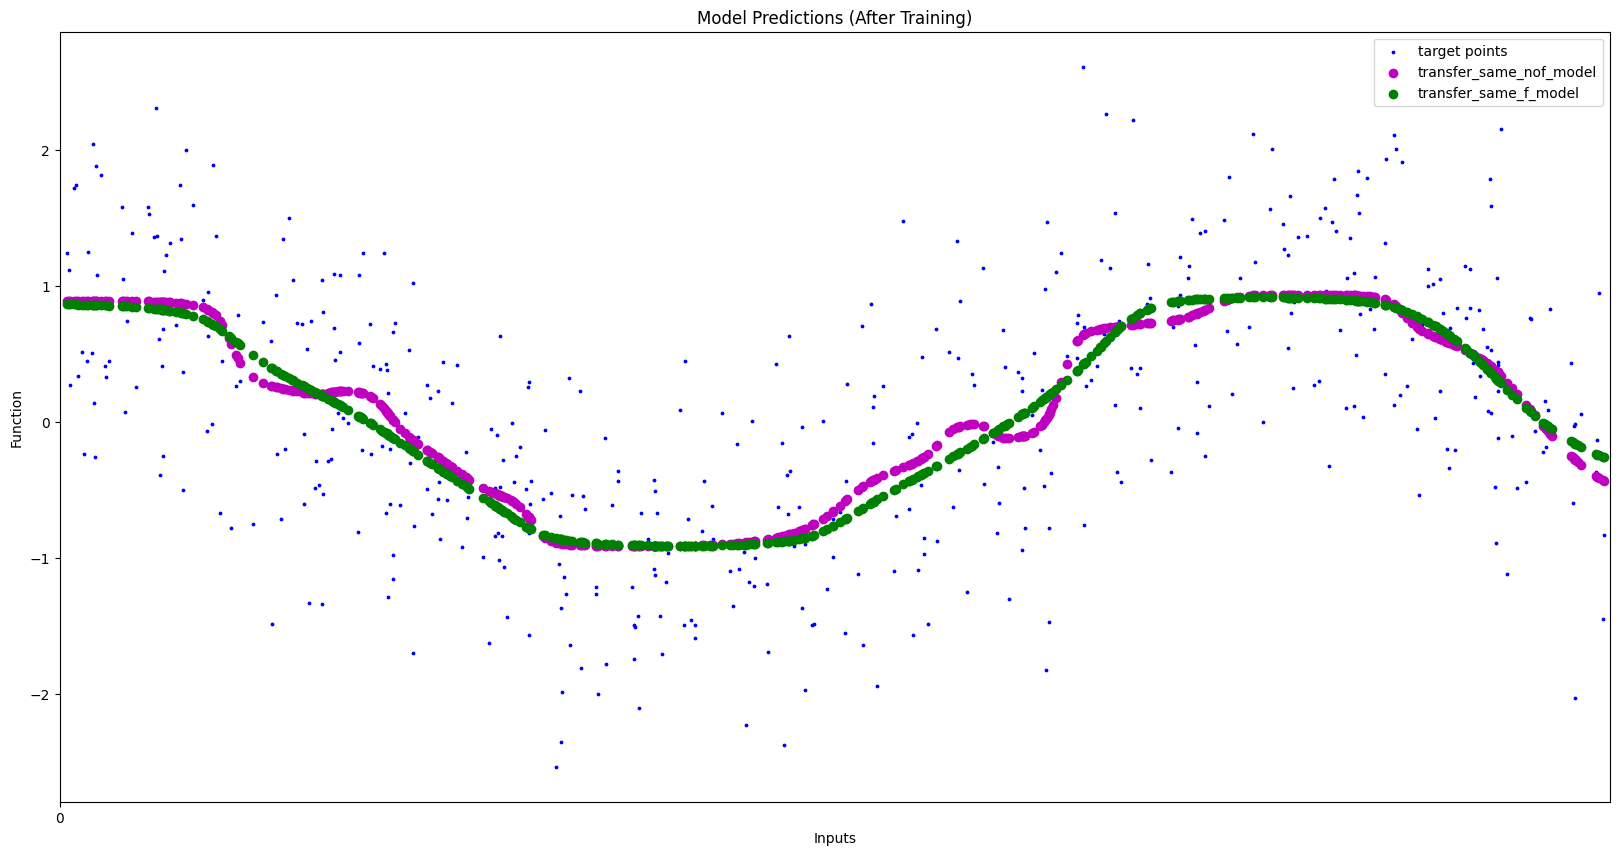

In [34]:
fig, ax = plt.subplots(figsize=(20,10))

#pred_over = np.load('./overfitted_model.npy')
#pred_corr = np.load('./correct_model.npy')

ax.scatter(train_inputs, train_targets, c='b', s=3, label='target points')
for i, model in enumerate(model_dict.keys()):
  if 'same' in model:
    colors = ['r', 'm', 'g', 'k', 'b', 'y']
    ax.scatter(train_inputs, all_preds[i], c=colors[i], label=model)
  #ax.scatter(train_inputs, all_preds[1], c='m', s=5, label='model 2')
  #ax.scatter(inputs, all_preds[2], c='g', s=5, label='model 3')

ax.set_xticks(range(0, 1))
plt.xlim(0, 1)
ax.set_xlabel('Inputs')
ax.set_ylabel('Function')
ax.set_title(f'Model Predictions (After Training)')
ax.legend(loc='upper right')
plt.show()

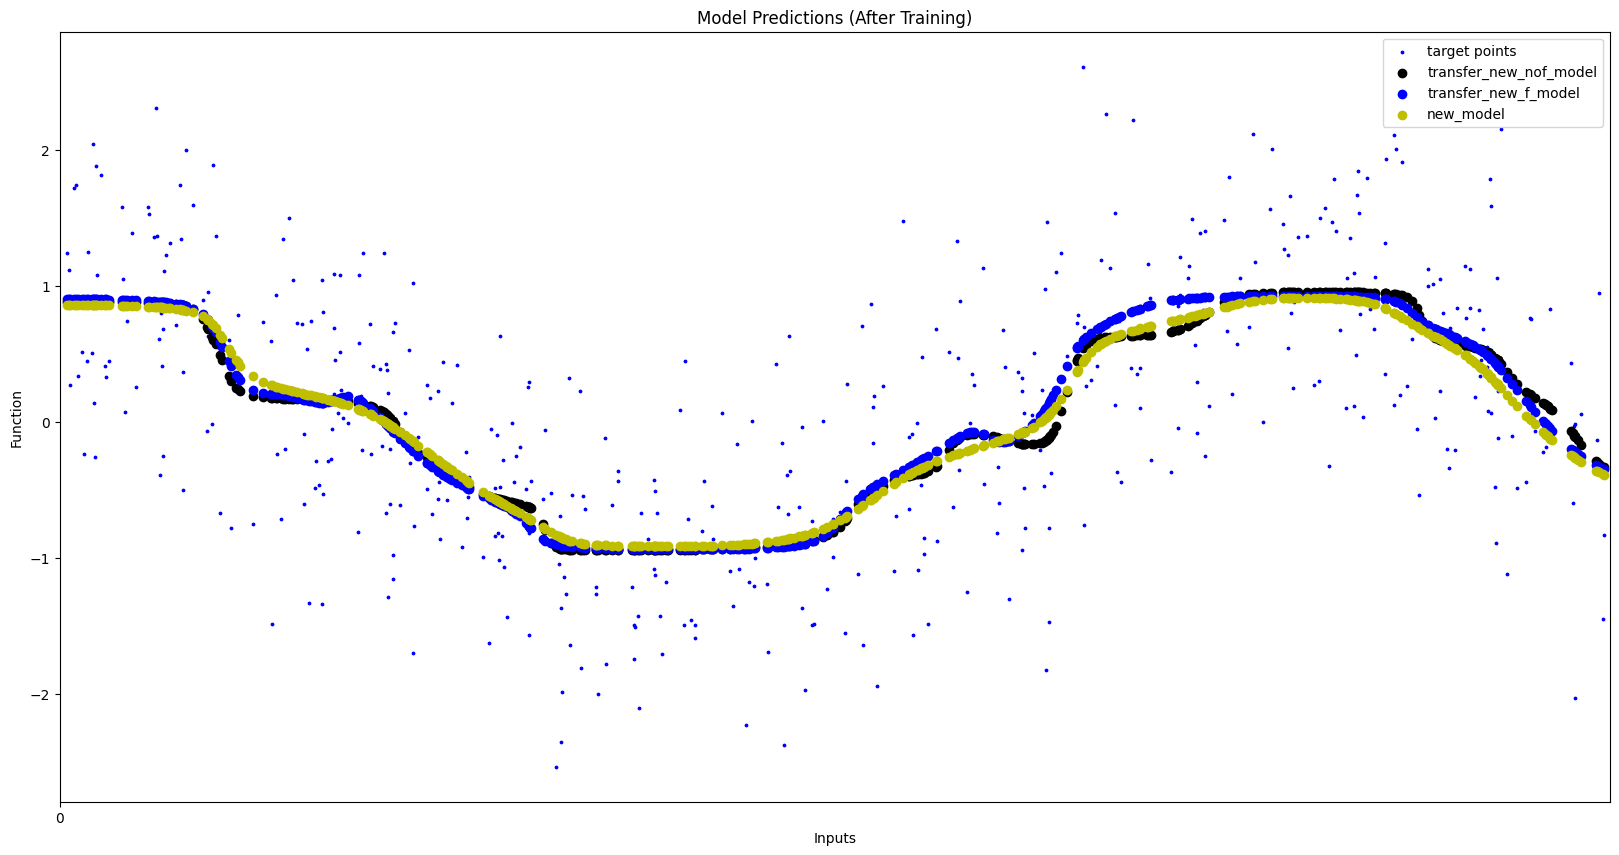

In [35]:
fig, ax = plt.subplots(figsize=(20,10))

#pred_over = np.load('./overfitted_model.npy')
#pred_corr = np.load('./correct_model.npy')

ax.scatter(train_inputs, train_targets, c='b', s=3, label='target points')
for i, model in enumerate(model_dict.keys()):
  if 'new' in model:
    colors = ['r', 'm', 'g', 'k', 'b', 'y']
    ax.scatter(train_inputs, all_preds[i], c=colors[i], label=model)
  #ax.scatter(train_inputs, all_preds[1], c='m', s=5, label='model 2')
  #ax.scatter(inputs, all_preds[2], c='g', s=5, label='model 3')

ax.set_xticks(range(0, 1))
plt.xlim(0, 1)
ax.set_xlabel('Inputs')
ax.set_ylabel('Function')
ax.set_title(f'Model Predictions (After Training)')
ax.legend(loc='upper right')
plt.show()

## Hints for Porject Proposal

Consider the Neural Matrix Factorization framework seen in the previous lecture. This framework allowed us to combine the GMF layers with the MLP layers in this way:
$$\phi^{GMF} = \mathbf{p_u}^G\odot \mathbf{q_i}^G$$
$$\phi^{MLP} = a_L(\mathbf{W}_L^T(a_{L-1}(...a_2 (\mathbf{W}_2^T \begin{bmatrix}
\mathbf{p_u} \\ \mathbf{q_i}
\end{bmatrix} + \mathbf{b}_2)...)) + \mathbf{b}_L)$$

$$ y_{ui} = \sigma(\mathbf{h}^T \begin{bmatrix}
\ \phi^{GMF} \\ \phi^{MLP}
\end{bmatrix})$$

<center>  <img src="https://drive.google.com/uc?export=view&id=1gNLUpiQdbDPMdvfZYVs3lcou3cd4Favb" width="550" height="400"> </center>

HINTS FOR PROJECT PROPOSAL:
Try to apply transfer learning to such an architecture.

- TASK 1: Train the GMF and MLP models separately, inspect and save the parameters.
- TASK 2: Use the pre-trained parameters for initializing the NMF architecture. In particular, use the pre-trained embeddings for users and items and the initialized layers of GMF and MLP.
- TASK 3: Finally, train the NMF model both by freezing the layers preceding the NeuMF layer and by keeping all the parameters trainable. Compare the performance with the network trained from scratch.


## Transfer Learning in Computer Vision

Now, we'll see how to train a convolutional neural network for image classification using transfer learning.

Very few people train an entire Convolutional Network from scratch (with random initialization), because it is relatively rare to have a dataset of sufficient size. Instead, it is common to pretrain a ConvNet on a very large dataset (e.g. ImageNet, which contains 1.2 million images with 1000 categories), and then use the ConvNet either as an initialization or a fixed feature extractor for the task of interest.

**ConvNet as fixed feature extractor**: we will freeze the weights for all of the network except that of the final fully connected layer. This last fully connected layer is replaced with a new one with random weights and only this layer is trained.

### Convolutional Neural Network

Convolutional Neural Networks are very similar to ordinary Neural Networks: they are made up of neurons that have learnable weights and biases. Each neuron receives some inputs, performs a dot product and optionally follows it with a non-linearity. The whole network still expresses a single differentiable score function: from the raw image pixels on one end to class scores at the other. And they still have a loss function (e.g. SVM/Softmax) on the last (fully-connected) layer and all the tips/tricks we developed for learning regular Neural Networks still apply.

Convolutional Neural Networks take advantage of the fact that the input consists of images and they constrain the architecture in a more sensible way. In particular, unlike a regular Neural Network, the layers of a ConvNet have neurons arranged in 3 dimensions: width, height, depth.

<center>  <img src="https://drive.google.com/uc?export=view&id=1K1KLGpeMvTgPQv750eIUEprYesvYA1HY" width="550" height="150"> </center>


A simple ConvNet is a sequence of layers, and every layer of a ConvNet transforms one volume of activations to another through a differentiable function. We use three main types of layers to build ConvNet architectures: **Convolutional Layer, Pooling Layer**, and **Fully-Connected Layer** (exactly as seen in regular Neural Networks). We will stack these layers to form a full ConvNet architecture.

Example Architecture:

* INPUT [32x32x3] will hold the raw pixel values of the image, in this case an image of width 32, height 32, and with three color channels R,G,B.
* CONV layer will compute the output of neurons that are connected to local regions in the input, each computing a dot product between their weights and a small region they are connected to in the input volume. This may result in volume such as [8x8x12] if we decided to use 12 filters.


In [ ]:
import IPython
IPython.display.HTML('<iframe src="https://cs231n.github.io/assets/conv-demo/index.html" width="100%" height="700px;" style="border:none;">')



* RELU layer will apply an elementwise activation function, such as the max(0,x)
 thresholding at zero. This leaves the size of the volume unchanged ([32x32x12]).
* POOL layer will perform a downsampling operation along the spatial dimensions (width, height), resulting in volume such as [16x16x12].


<center>  <img src="https://drive.google.com/uc?export=view&id=1kzRVzL6mVC3nFQkyAEKy-c2_4IuyPS-Y" width="550" height="185"> </center>


* FC (i.e. fully-connected) layer will compute the class scores, resulting in volume of size [1x1xN], where each of the N numbers correspond to a class score. As with ordinary Neural Networks and as the name implies, each neuron in this layer will be connected to all the numbers in the previous volume.

In this way, ConvNets transform the original image layer by layer from the original pixel values to the final class scores. Note that some layers contain parameters and other don’t. In particular, the CONV/FC layers perform transformations that are a function of not only the activations in the input volume, but also of the parameters (the weights and biases of the neurons). On the other hand, the RELU/POOL layers will implement a fixed function. The parameters in the CONV/FC layers will be trained with gradient descent so that the class scores that the ConvNet computes are consistent with the labels in the training set for each image.

## Introduction to `torchvision`

`torchvision` is a library in the PyTorch ecosystem specifically designed for computer vision tasks. It provides tools for handling image data, including datasets, transformations, pre-trained models, and utilities for working with images. This makes it a crucial component when working with deep learning models for vision applications.

### Main Components of `torchvision`

The `torchvision` package consists of four main modules:

1. **`torchvision.datasets`** – Provides standard datasets for easy access and loading.
2. **`torchvision.transforms`** – Includes various transformations to preprocess and augment image data.
3. **`torchvision.models`** – Contains pre-trained deep learning models that can be used for transfer learning.
4. **`torchvision.utils`** – Provides utilities for visualizing images and model predictions.


---

### `torchvision.datasets`

`torchvision.datasets` provides many standard datasets such as ImageNet, CIFAR-10, and MNIST. These datasets can be easily loaded using PyTorch’s `DataLoader` for efficient batch processing.

**Example**:
```python
from torchvision import datasets
from torch.utils.data import DataLoader

# Load CIFAR-10 dataset
train_dataset = datasets.CIFAR10(root="./data", train=True, download=True)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
```

### `torchvision.transforms`

Transforms allow us to preprocess images before feeding them into a neural network. They are commonly used for resizing, normalizing, converting to tensors, and augmenting data.

**Example**:
```python
from torchvision import transforms  

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to match model input size
    transforms.RandomHorizontalFlip(),  # Data augmentation
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])

# Load CIFAR-10 dataset
train_dataset = datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
```

---

### `torchvision.models`

`torchvision.models` provides pre-trained models that can be used for transfer learning. These models are trained on large datasets (e.g., ImageNet) and can be fine-tuned for custom tasks. Some popular pre-trained models are :

- `models.resnet18()` – ResNet-18
- `models.vgg16()` – VGG-16
- `models.mobilenet_v2()` – MobileNetV2
- `models.efficientnet_b0()` – EfficientNet-B0

These models allow us to leverage learned features and fine-tune them for specific tasks, reducing training time and improving performance.

**Example**:
```python
import torchvision.models as models
import torch.nn as nn

# Load a pre-trained ResNet model
model = models.resnet18(pretrained=True)

# Modify the final classification layer for a custom task
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)  # Assuming 10 output classes
```
---

### `torchvision.utils`

This module provides utilities for working with images and model predictions. The most useful function in this context is `make_grid`, which helps visualize batches of images.

**Example**:
```python
import torchvision.utils as vutils
import matplotlib.pyplot as plt

# Get a batch of images from the DataLoader
images, _ = next(iter(train_loader))

# Create a grid of images
img_grid = vutils.make_grid(images[:16], nrow=4, normalize=True)

# Display the grid
plt.figure(figsize=(8,8))
plt.imshow(img_grid.permute(1, 2, 0))
plt.axis("off")
plt.show()
nginx
Copia
Modifica


In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

## Image Classification Use Case
Let's now use a pre-trained CNN model with torchvision to train a custom image classifier model by applying tranfer learning.

### Load Data

We will use torchvision and torch.utils.data packages for loading the
data.

The problem we\'re going to solve today is to train a model to classify
**ants** and **bees**. We have about 120 training images each for ants
and bees. There are 75 validation images for each class. Usually, this
is a very small dataset to generalize upon, if trained from scratch.
Since we are using transfer learning, we should be able to generalize
reasonably well.

This dataset is a very small subset of imagenet. Download it from here: https://download.pytorch.org/tutorial/hymenoptera_data.zip

In [37]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'drive/MyDrive/Colab Notebooks/3 - Data/hymenoptera_data/'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device =  "cpu"
print(f"Using {device} device")

Using cpu device


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [38]:
class_names

['ants', 'bees']

### Visualize a few images

Let\'s visualize a few training images so as to understand the data
augmentations.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


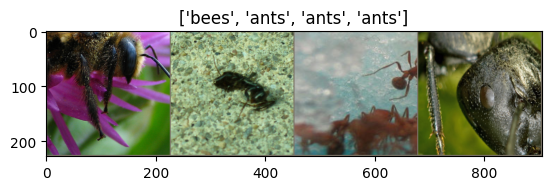

In [39]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

### Training the model


Now, let\'s write a general function to train a model. Here, we will
illustrate:

-   Scheduling the learning rate
-   Saving the best model

In the following, parameter `scheduler` is an LR scheduler object from
`torch.optim.lr_scheduler`.

In [40]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    basedir = 'drive/MyDrive/Colab Notebooks/3 - Models/'
    best_model_params_path = os.path.join(basedir, 'best_model_params.pt')

    torch.save(model.state_dict(), best_model_params_path)
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), best_model_params_path)

        print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

### Visualizing the model predictions

Generic function to display predictions for a few images

In [41]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

### Finetuning the ConvNet

Load a pretrained model and reset final fully connected layer.

In [42]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 142MB/s]


### Train and evaluate

It should take around 15-25 min on CPU. On GPU though, it takes less
than a minute.


In [43]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5057 Acc: 0.7510
val Loss: 0.2057 Acc: 0.9150

Training complete in 1m 46s
Best val Acc: 0.915033
Epoch 1/24
----------
train Loss: 0.5468 Acc: 0.7787
val Loss: 0.2193 Acc: 0.9216

Training complete in 3m 20s
Best val Acc: 0.921569
Epoch 2/24
----------
train Loss: 0.4783 Acc: 0.8340
val Loss: 0.2451 Acc: 0.8954

Training complete in 4m 53s
Best val Acc: 0.921569
Epoch 3/24
----------
train Loss: 0.3839 Acc: 0.8379
val Loss: 0.4424 Acc: 0.8497

Training complete in 6m 24s
Best val Acc: 0.921569
Epoch 4/24
----------
train Loss: 0.5272 Acc: 0.7984
val Loss: 0.2640 Acc: 0.8693

Training complete in 7m 55s
Best val Acc: 0.921569
Epoch 5/24
----------
train Loss: 0.5061 Acc: 0.7945
val Loss: 0.5113 Acc: 0.8497

Training complete in 9m 27s
Best val Acc: 0.921569
Epoch 6/24
----------
train Loss: 0.5949 Acc: 0.7589
val Loss: 0.2834 Acc: 0.8954

Training complete in 10m 58s
Best val Acc: 0.921569
Epoch 7/24
----------
train Loss: 0.3614 Acc: 0.8340
val Loss

In [ ]:
visualize_model(model_ft)

### ConvNet as fixed feature extractor

Here, we need to freeze all the network except the final layer. We need
to set `requires_grad = False` to freeze the parameters so that the
gradients are not computed in `backward()`.

In [44]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

### Train and evaluate the freezed model

On CPU this will take about half the time compared to previous scenario.
This is expected as gradients don\'t need to be computed for most of the
network. However, forward does need to be computed.


In [45]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=5)

Epoch 0/4
----------
train Loss: 0.6602 Acc: 0.6522
val Loss: 1.2207 Acc: 0.5621

Training complete in 0m 47s
Best val Acc: 0.562092
Epoch 1/4
----------
train Loss: 0.8374 Acc: 0.6680
val Loss: 0.1890 Acc: 0.9412

Training complete in 1m 33s
Best val Acc: 0.941176
Epoch 2/4
----------
train Loss: 0.5053 Acc: 0.7945
val Loss: 0.1790 Acc: 0.9281

Training complete in 2m 18s
Best val Acc: 0.941176
Epoch 3/4
----------
train Loss: 0.4334 Acc: 0.8103
val Loss: 0.2210 Acc: 0.9346

Training complete in 3m 2s
Best val Acc: 0.941176
Epoch 4/4
----------
train Loss: 0.4637 Acc: 0.8024
val Loss: 0.2071 Acc: 0.9412

Training complete in 3m 46s
Best val Acc: 0.941176


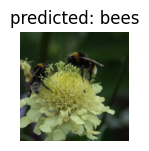

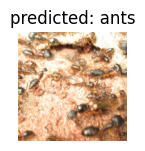

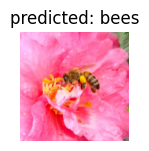

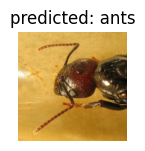

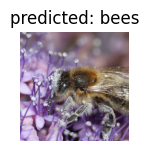

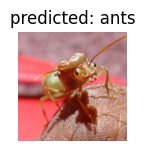

In [46]:
visualize_model(model_conv)

plt.ioff()
plt.show()

### Inference on custom images

Use the trained model to make predictions on custom images and visualize
the predicted class labels along with the images.

In [47]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

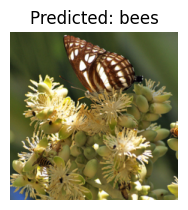

In [48]:
visualize_model_predictions(
    model_conv,
    img_path=data_dir+'val/bees/72100438_73de9f17af.jpg'
)

plt.ioff()
plt.show()

It would be interesting to understand why the model has predicted bee.
